In [1]:
import pandas as pd
import numpy as np
import importlib

import plotly.express as px

import irina.utility_functions as uf

In [2]:
year_list = range(1970, 2023)
mode = "collaborative_"

In [3]:
df_prob_yearly_list = []

for year_loop in year_list:
    df_tmp = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}{year_loop}.csv", index_col=0)
    df_prob_yearly_list.append(
        df_tmp.div(df_tmp.sum(axis=1), axis=0).reset_index().assign(year=year_loop)
    )

df_prob_yearly = pd.concat(df_prob_yearly_list)

In [4]:
df_prob_yearly

,country,1100,1102,1103,1104,1105,1106,1107,1108,1109,...,1212,2104,1409,2922,1410,2402,2714,1200,2718,3002
0,AE,NaN,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AL,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,WS,NaN,NaN,0.022727,NaN,NaN,0.068182,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213,YE,0.001717,0.000858,0.003433,0.005150,0.006009,0.010300,NaN,NaN,0.000858,...,NaN,NaN,NaN,NaN,NaN,0.001717,NaN,NaN,NaN,NaN
214,ZA,0.002353,0.003326,0.003732,0.001136,0.012169,0.007870,0.000974,0.000243,0.004706,...,0.000730,NaN,0.000406,NaN,NaN,0.001947,0.000162,NaN,0.000730,NaN
215,ZM,0.007614,0.006345,0.002538,0.002538,0.008883,0.008883,0.002538,0.001269,0.006345,...,0.001269,NaN,NaN,NaN,NaN,0.012690,NaN,NaN,0.001269,NaN


In [5]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [10]:
country = "CN"
df_country = (
    df_prob_yearly
    .query("country == @country")
    .drop("country", axis=1)
    .set_index("year")
)
# df_country

In [11]:
df_dist = uf.get_w1_distances(subfield_tree, df_country)

In [13]:
uf.plotly_heatmap(
    df_dist,
    x_labels=df_dist.columns.astype(str),
    y_labels=df_dist.index,
    colorscale="non-symmetric",
    line_height=10,
    z_min=0,
    z_max=0.2,
    title=f"Stability {uf.id2name_country[country]}"
)

In [9]:
# uf.plotly_heatmap(
#     df_country,
#     x_labels=df_country.columns,
#     y_labels=df_country.index,
#     x_type="subfield",
#     z_min=0,
#     z_max=0.02,
#     colorscale="non",
#     line_height=10,
#     title=f"Scientific fingerprints {uf.id2name_country[country]}"
# )

# Pipeline years

In [141]:
df_dist_yearly_list = []
for country_loop in df_prob_yearly.country.unique():
    # print(country_loop)
    df_country = (
        df_prob_yearly
        .query("country == @country_loop")
        .drop("country", axis=1)
        .set_index("year")
    )
    df_dist = uf.get_w1_distances(subfield_tree, df_country)
    df_country_stat = pd.DataFrame({}, index=df_dist.index)
    df_country_stat["country"] = country_loop
    df_country_stat["from_start"] = df_dist.iloc[0]
    df_country_stat["diag"] = np.concatenate([[0], np.diagonal(df_dist.values, 1)])
    df_dist_yearly_list.append(df_country_stat.reset_index())
df_dist_yearly = pd.concat(df_dist_yearly_list)

In [142]:
df_dist_yearly.head()

,index,country,from_start,diag
0,1970,AE,0.000000,0.000000
1,1971,AE,0.188288,0.188288
2,1972,AE,0.900000,0.774775
3,1973,AE,0.757529,0.180180
4,1974,AE,0.909910,0.199485


In [143]:
# df_dist_yearly.to_csv(uf.PATH+f"df_w1_dist_yearly_{mode[:-1]}.csv", index=False)

In [144]:
px.box(
    df_dist_yearly,
    x="index",
    y="diag",
    hover_data="country",
)

In [145]:
df_dist_yearly

,index,country,from_start,diag
0,1970,AE,0.000000,0.000000
1,1971,AE,0.188288,0.188288
2,1972,AE,0.900000,0.774775
3,1973,AE,0.757529,0.180180
4,1974,AE,0.909910,0.199485
...,...,...,...,...
14,2019,TL,0.522523,0.122556
15,2020,TL,0.486759,0.206061
16,2021,TL,0.549550,0.344253
17,2022,TL,0.545392,0.354711


In [156]:
country_list = ["US" ,"CN", "ID", "IN", "FR", "RU", "UA", "AF"]
px.line(
    (
        df_dist_yearly
        .query("country in @country_list")
    ),
    x="index",
    y="diag",
    color="country"
)

In [147]:
px.bar((
    df_dist_yearly
    .groupby("country")
    .diag
    .std()
))

In [148]:
df_stability = (
    df_dist_yearly
    .groupby("country", as_index=False)
    .diag
    .std()
    .merge(uf.df_country[["alpha-2", "alpha-3", "sub-region", "region"]], left_on="country", right_on="alpha-2", how="left")
)

(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'Stability collaborative '}>)

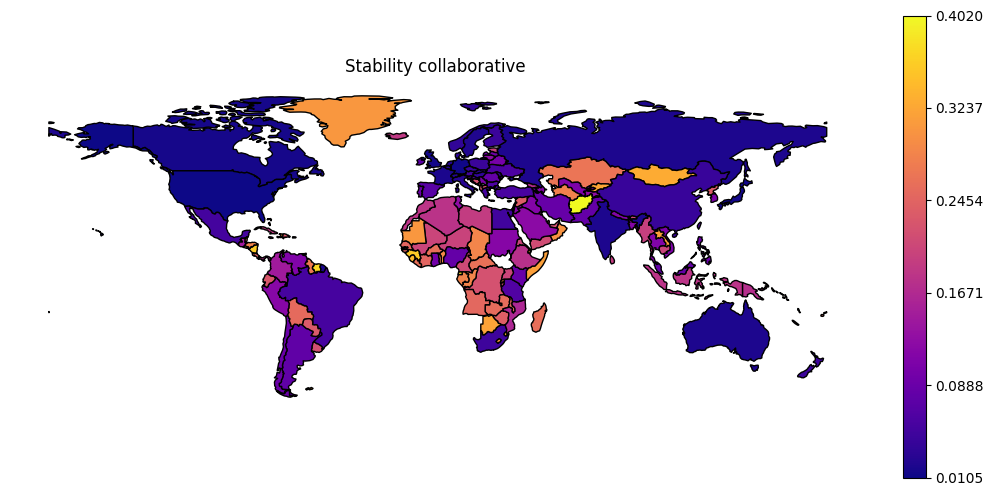

In [149]:
uf.plot_map_continuous(df_stability, "diag", title=f"Stability {mode[:-1]}")